# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty.

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [37]:
%pip install --upgrade plotly

## Import Statements

In [38]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [39]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [40]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames?
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [41]:
print(f"{df_hh_income.shape}")
print(f"{df_pct_poverty.shape}")
print(f"{df_pct_completed_hs.shape}")
print(f"{df_share_race_city.shape}")

(29322, 3)
(29329, 3)
(29329, 3)
(29268, 7)


In [42]:
display(df_hh_income.columns)
display(df_pct_poverty.columns)
display(df_pct_completed_hs.columns)
display(df_share_race_city.columns)


Index(['Geographic Area', 'City', 'Median Income'], dtype='object')

Index(['Geographic Area', 'City', 'poverty_rate'], dtype='object')

Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='object')

Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='object')

## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate.

In [43]:
print('Missing values in df_hh_income:')
display(df_hh_income.isnull().sum())
print('\nMissing values in df_pct_poverty:')
display(df_pct_poverty.isnull().sum())
print('\nMissing values in df_pct_completed_hs:')
display(df_pct_completed_hs.isnull().sum())
print('\nMissing values in df_share_race_city:')
display(df_share_race_city.isnull().sum())
print('\nMissing values in df_fatalities:')
display(df_fatalities.isnull().sum())

Missing values in df_hh_income:


,0
Geographic Area,0
City,0
Median Income,51



Missing values in df_pct_poverty:


,0
Geographic Area,0
City,0
poverty_rate,0



Missing values in df_pct_completed_hs:


,0
Geographic Area,0
City,0
percent_completed_hs,0



Missing values in df_share_race_city:


,0
Geographic area,0
City,0
share_white,0
share_black,0
share_native_american,0
share_asian,0
share_hispanic,0



Missing values in df_fatalities:


,0
id,0
name,0
date,0
manner_of_death,0
armed,9
age,77
gender,0
race,195
city,0
state,0


In [44]:
print('Duplicates in df_hh_income:', df_hh_income.duplicated().sum())
print('Duplicates in df_pct_poverty:', df_pct_poverty.duplicated().sum())
print('Duplicates in df_pct_completed_hs:', df_pct_completed_hs.duplicated().sum())
print('Duplicates in df_share_race_city:', df_share_race_city.duplicated().sum())
print('Duplicates in df_fatalities:', df_fatalities.duplicated().sum())

Duplicates in df_hh_income: 0
Duplicates in df_pct_poverty: 0
Duplicates in df_pct_completed_hs: 0
Duplicates in df_share_race_city: 0
Duplicates in df_fatalities: 0


In [45]:
df_pct_poverty.poverty_rate = pd.to_numeric(df_pct_poverty.poverty_rate, errors='coerce')

In [46]:
print(df_pct_poverty.poverty_rate.isna().sum())

201


In [47]:
df_pct_poverty.poverty_rate = df_pct_poverty.poverty_rate.fillna(0)

In [48]:

df_hh_income['Median Income'] = df_hh_income['Median Income'].astype(str).str.replace(",", "", regex=False)
df_hh_income['Median Income'] = df_hh_income['Median Income'].astype(str).str.replace("$", "", regex=False)
df_hh_income['Median Income'] = df_hh_income['Median Income'].astype(str).str.replace("+", "", regex=False)
df_hh_income['Median Income'] = df_hh_income['Median Income'].astype(str).str.replace("-", "", regex=False)


df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'], errors='coerce')


print(df_hh_income['Median Income'].isna().sum())

1904


In [49]:
df_pct_completed_hs.percent_completed_hs = pd.to_numeric(df_pct_completed_hs.percent_completed_hs, errors='coerce')
df_pct_completed_hs.percent_completed_hs.fillna(0, inplace=True)

/tmp/ipykernel_3582/3818382778.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pct_completed_hs.percent_completed_hs.fillna(0, inplace=True)


In [50]:

race_columns = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']

for col in race_columns:
    df_share_race_city[col] = pd.to_numeric(df_share_race_city[col], errors='coerce')
    df_share_race_city[col].fillna(0, inplace=True)

/tmp/ipykernel_3582/455163294.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_share_race_city[col].fillna(0, inplace=True)


In [51]:
df_fatalities.age.fillna(df_fatalities.age.mean(), inplace=True)

df_fatalities.race.fillna('Unknown', inplace=True)
df_fatalities.armed.fillna('Unknown', inplace=True)

/tmp/ipykernel_3582/3081291938.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fatalities.age.fillna(df_fatalities.age.mean(), inplace=True)
/tmp/ipykernel_3582/3081291938.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [52]:
print(df_pct_poverty.isna().sum())
print(df_share_race_city.isna().sum())

Geographic Area    0
City               0
poverty_rate       0
dtype: int64
Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [62]:
state_proverty = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().reset_index()
state_proverty.sort_values(by='poverty_rate', ascending=False, inplace=True)

In [64]:
bar_proverty = px.bar(
    state_proverty,
    x='Geographic Area',
    y='poverty_rate',
)

bar_proverty.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [67]:
state_graduation = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().reset_index()
state_graduation.sort_values(by="percent_completed_hs", ascending=True , inplace=True)

In [68]:
graduation_plot = px.bar(
    state_graduation,
    x='Geographic Area',
    y='percent_completed_hs',
)

graduation_plot.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

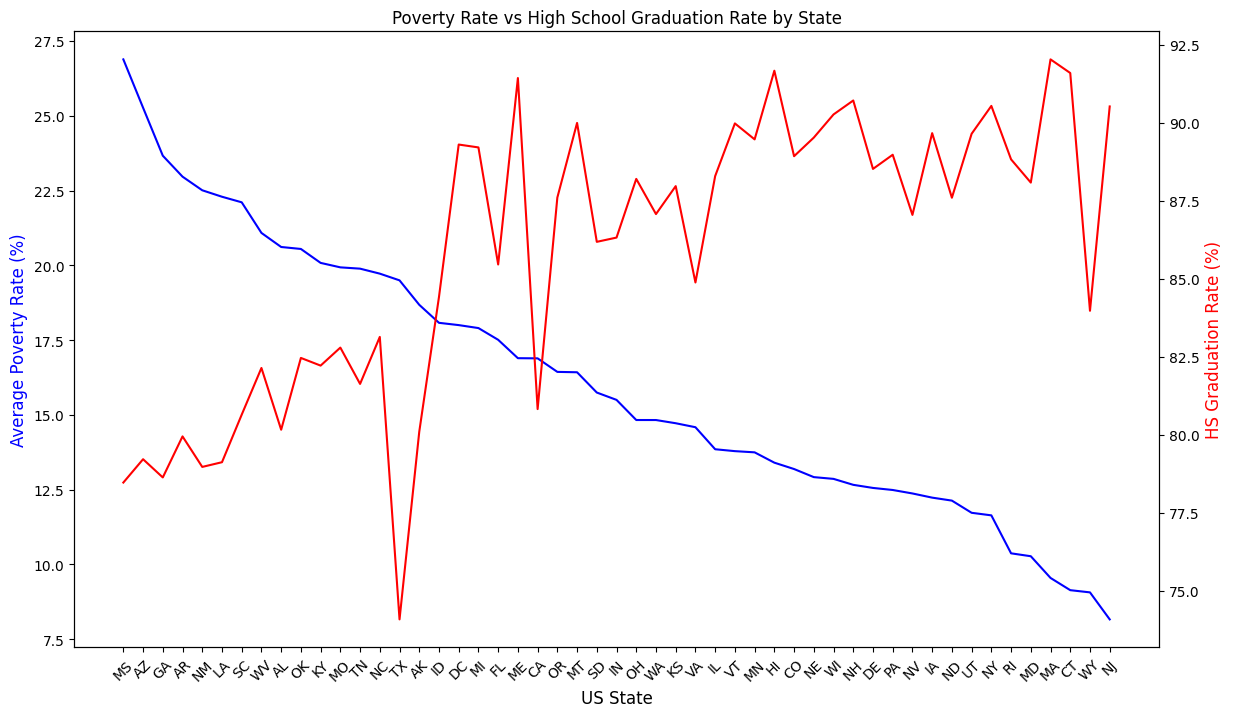

In [72]:
df_merged = pd.merge(state_proverty, state_graduation, on='Geographic Area')
df_merged = df_merged.sort_values('poverty_rate', ascending=False)

plt.figure(figsize=(14, 8))
plt.title('Poverty Rate vs High School Graduation Rate by State')


ax1 = plt.gca()

ax2 = ax1.twinx()

ax1.plot(df_merged['Geographic Area'], df_merged['poverty_rate'], color='blue', label='Poverty Rate')
ax2.plot(df_merged['Geographic Area'], df_merged['percent_completed_hs'], color='red', label='HS Graduation Rate')


ax1.set_ylabel('Average Poverty Rate (%)', color='blue', fontsize=12)
ax2.set_ylabel('HS Graduation Rate (%)', color='red', fontsize=12)
ax1.set_xlabel('US State', fontsize=12)


ax1.tick_params(axis='x', rotation=45)

plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

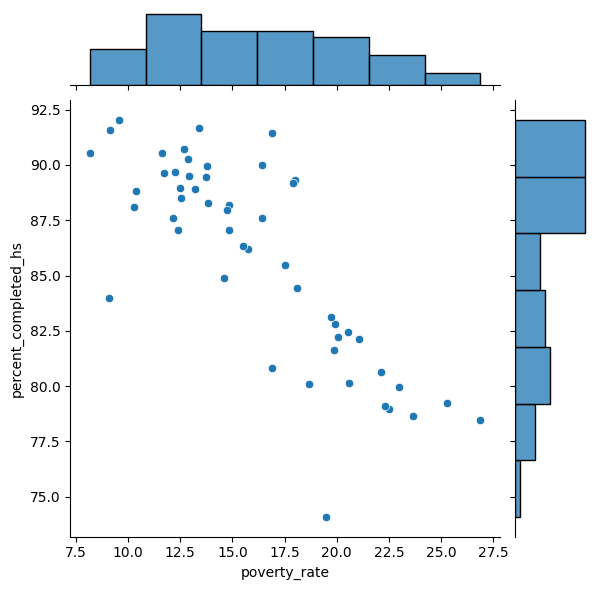

In [74]:
sns_join = sns.jointplot(
    x=df_merged['poverty_rate'],
    y=df_merged['percent_completed_hs'],
    data=df_merged,
    kind='scatter'
)

plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio.

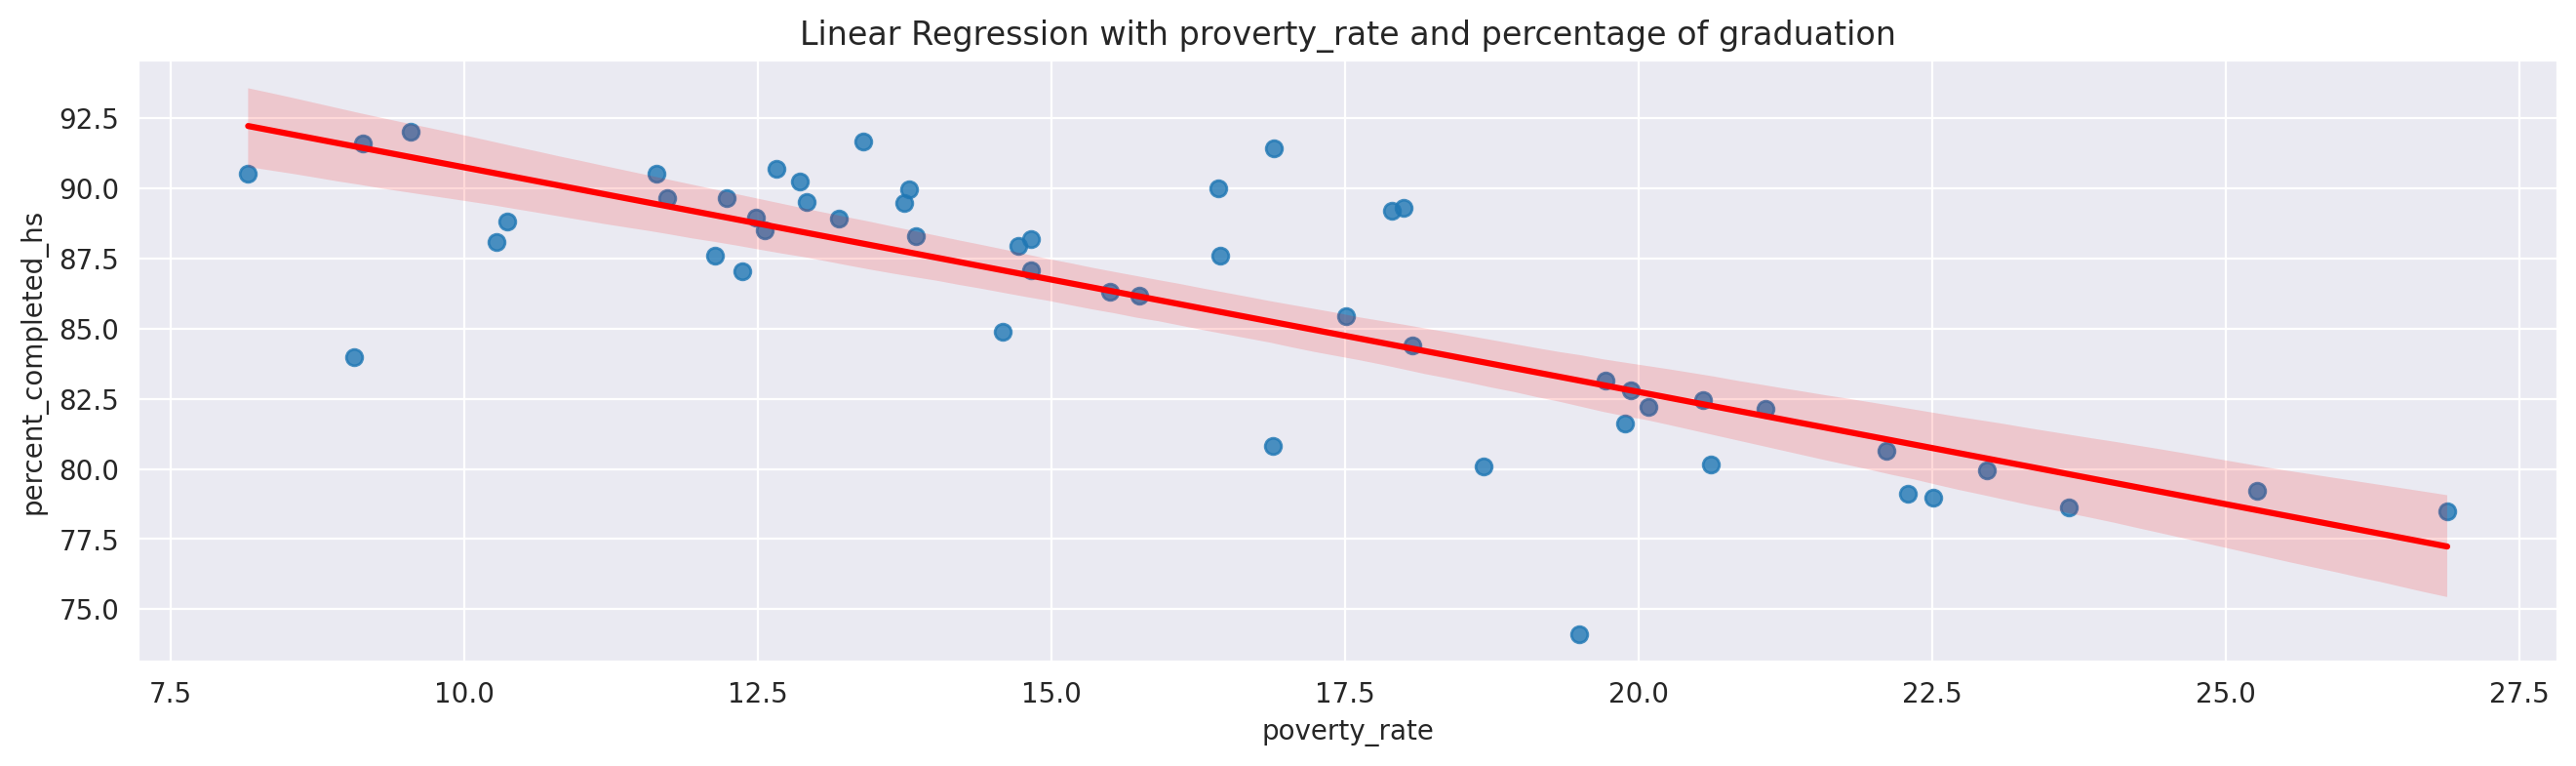

In [78]:
plt.figure(figsize=(16, 4), dpi=200)

with sns.axes_style("darkgrid"):
  sns.regplot(
      data=df_merged,
      x="poverty_rate",
      y="percent_completed_hs",
      lowess=False,
      line_kws={'color': 'red'}
  )

plt.title("Linear Regression with proverty_rate and percentage of graduation")
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections.

In [83]:

race_cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
share_summary = df_share_race_city.groupby("Geographic area")[race_cols].mean().reset_index()
share_summary

,Geographic area,share_white,share_black,share_native_american,share_asian,share_hispanic
0,AK,45.26,0.56,45.48,1.38,2.13
1,AL,72.51,23.32,0.66,0.48,2.98
2,AR,78.45,16.30,0.76,0.48,4.27
3,AZ,59.93,0.95,28.59,0.73,20.14
4,CA,71.54,2.68,1.72,5.54,29.51
5,CO,87.77,0.92,1.62,1.15,17.90
6,CT,86.11,4.99,0.66,2.99,7.98
7,DC,38.50,50.70,0.30,3.50,9.10
8,DE,76.25,15.39,0.52,2.00,7.42
9,FL,78.67,13.37,0.46,1.62,16.53


In [86]:
fig = px.bar(share_summary,
             x="Geographic area",
             y=['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic'],
             title="Racial Makeup by US State",
             labels={'value':'Percentage Share', 'variable':'Race'},
             barmode='stack') # This ensures they are stacked

fig.show()


# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [87]:
race_deaths = df_fatalities.race.value_counts()
print(race_deaths)

race
W          1201
B           618
H           423
Unknown     195
A            39
N            31
O            28
Name: count, dtype: int64


In [88]:
fig = px.pie(labels=race_deaths.index,
             values=race_deaths.values,
             title="Percentage of Fatalities by Race",
             names=race_deaths.index,
             hole=0.5)


fig.update_traces(textposition='inside', textinfo='percent+label')

fig.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women.

In [91]:
gender_df = df_fatalities.gender.value_counts()

In [92]:
gender_plot = px.bar(
    x=gender_df.index,
    y=gender_df.values,
    title="Total Number of Deaths by Gender",
)

gender_plot.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death?

In [93]:
box_plot = px.box(df_fatalities,
                  x='manner_of_death',
                  y='age',
                  color='gender',
                  title='Age Distribution by Manner of Death and Gender')

# This helps make the chart more readable
box_plot.update_layout(xaxis_title='Manner of Death',
                       yaxis_title='Age of Deceased')

box_plot.show()

# Were People Armed?

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed?

In [95]:
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [96]:
armed_counts = df_fatalities.armed.value_counts()
print(armed_counts.head(15))

armed
gun               1398
knife              373
vehicle            177
unarmed            171
undetermined       117
toy weapon         104
machete             18
unknown weapon      18
Taser                9
ax                   9
Unknown              9
baseball bat         8
sword                8
metal pipe           7
box cutter           7
Name: count, dtype: int64


In [97]:
top_weapons = armed_counts[:10]

fig = px.bar(x=top_weapons.index,
             y=top_weapons.values,
             title='Top 10 Weapons Carried by Deceased',
             labels={'x': 'Weapon Type', 'y': 'Number of Incidents'})

fig.show()

In [98]:
gunned_killing = armed_counts['gun']
unarmed_killing = armed_counts['unarmed']

total_fatalities  = len(df_fatalities)

gunned_percentage = (gunned_killing / total_fatalities) * 100
unarmed_percentage = (unarmed_killing / total_fatalities) * 100

print(f"Percentage of people killed by police who were armed with guns: {gunned_percentage:.2f}%")
print(f"Percentage of people killed by police who were unarmed: {unarmed_percentage:.2f}%")

Percentage of people killed by police who were armed with guns: 55.15%
Percentage of people killed by police who were unarmed: 6.75%


# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [99]:
under_25 = df_fatalities[df_fatalities['age'] < 25]
print(len(under_25))

450


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police.

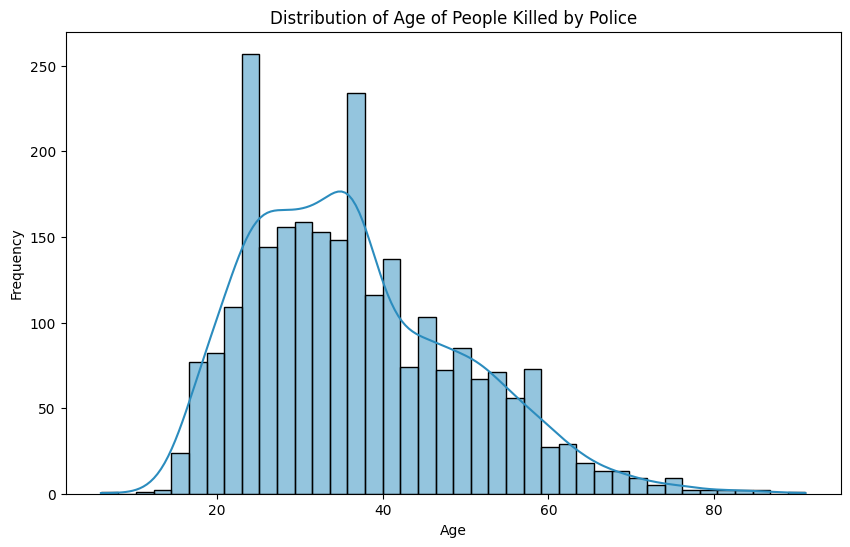

In [105]:
plt.figure(figsize=(10, 6))

sns.histplot(df_fatalities.age,
             kde=True,
             bins=40,
             color='#2b8cbe')

plt.title('Distribution of Age of People Killed by Police')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions?

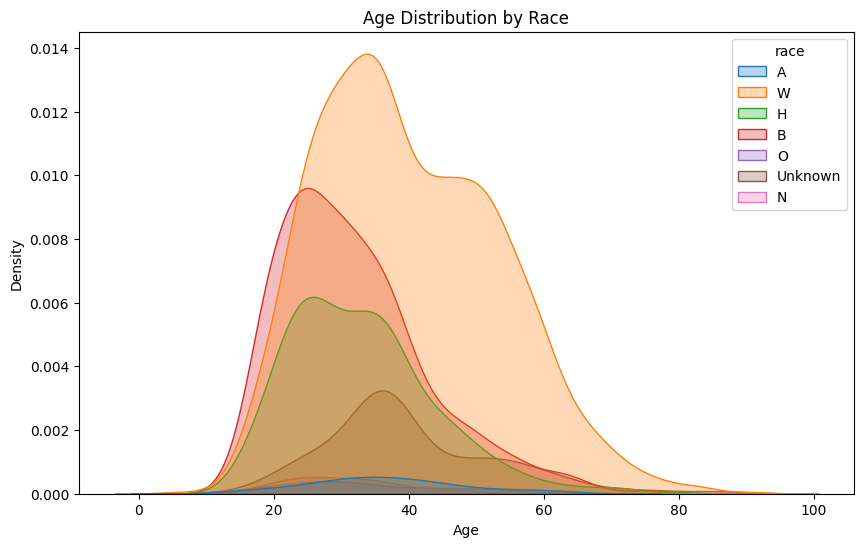

In [106]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df_fatalities,
            x='age',
            hue='race',
            fill=True,
            alpha=0.3)

plt.title('Age Distribution by Race')
plt.xlabel('Age')
plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race.

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [108]:
fatalities_with_illness = df_fatalities[df_fatalities['signs_of_mental_illness'] == True]

In [109]:
print(f"Percentage of people killed by police have been diagnored with mental illness is {(len(fatalities_with_illness)/len(df_fatalities))*100}")

Percentage of people killed by police have been diagnored with mental illness is 24.970414201183434


# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [110]:
city_fatalities = df_fatalities.city.value_counts()

top_10_cities = city_fatalities.head(10)

print(top_10_cities)

city
Los Angeles    39
Phoenix        31
Houston        27
Chicago        25
Las Vegas      21
San Antonio    20
Columbus       19
Miami          18
Austin         18
St. Louis      15
Name: count, dtype: int64


In [111]:
fig = px.bar(x=top_10_cities.index,
             y=top_10_cities.values,
             title='Top 10 Cities with the Most Police Killings',
             labels={'x': 'City', 'y': 'Number of Killings'},
             color=top_10_cities.values,
             color_continuous_scale='Reds')

fig.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city.

In [113]:
# 1. Get the names of the top 10 cities
top_10_city_names = df_fatalities.city.value_counts().head(10).index.tolist()

# 2. Filter your killings data for only these 10 cities
top_10_killings = df_fatalities[df_fatalities.city.isin(top_10_city_names)]

killing_counts = top_10_killings.groupby(['city', 'race']).size().unstack(fill_value=0)
print(killing_counts)

race         A   B   H  N  O  Unknown   W
city                                     
Austin       0   3   2  0  0        0  13
Chicago      0  21   1  0  0        1   2
Columbus     0  11   0  0  1        1   6
Houston      1  15   6  1  0        1   3
Las Vegas    0   3   5  0  0        4   9
Los Angeles  1  10  19  0  0        3   6
Miami        0   8   6  0  0        1   3
Phoenix      0   2  11  3  0        3  12
San Antonio  0   3  12  0  0        2   3
St. Louis    0  11   0  0  0        1   3


In [114]:
# 1. Create a copy so we don't mess up the original data
df_share_cleaned = df_share_race_city.copy()
df_share_cleaned['City'] = df_share_cleaned['City'].str.replace(' city| town| CDP', '', regex=True)

city_demographics = df_share_cleaned[df_share_cleaned['City'].isin(top_10_city_names)]

city_demographics = city_demographics.groupby('City')[race_cols].mean()

print(city_demographics)

             share_white  share_black  share_native_american  share_asian  \
City                                                                        
Austin             88.44         2.68                   0.46         1.96   
Chicago            45.00        32.90                   0.50         5.50   
Columbus           79.91        12.66                   0.74         1.55   
Houston            81.47        10.14                   1.29         1.21   
Las Vegas          63.50         6.50                   1.40         3.50   
Los Angeles        56.70         9.35                   0.35         5.65   
Miami              81.40         4.32                   4.04         0.38   
Phoenix            74.95         3.70                   1.85         2.25   
San Antonio        88.30         2.67                   0.50         1.13   
St. Louis          65.27        26.10                   3.67         1.03   

             share_hispanic  
City                         
Austin         

In [115]:

race_map = {'W': 'share_white', 'B': 'share_black', 'H': 'share_hispanic',
            'A': 'share_asian', 'N': 'share_native_american'}


top_10_city_names = df_fatalities.city.value_counts().head(10).index.tolist()
killings_top10 = df_fatalities[df_fatalities.city.isin(top_10_city_names)].copy()
killings_top10['race_label'] = killings_top10['race'].map(race_map)

killing_stats = killings_top10.groupby(['city', 'race_label']).size().unstack(fill_value=0)
killing_pcts = killing_stats.div(killing_stats.sum(axis=1), axis=0) * 100
killing_pcts = killing_pcts.reset_index().melt(id_vars='city', var_name='race', value_name='pct')
killing_pcts['Data Type'] = 'Killings %'

In [116]:

pop_pcts = city_demographics.reset_index().rename(columns={'City': 'city'})
pop_pcts = pop_pcts.melt(id_vars='city', var_name='race', value_name='pct')
pop_pcts['Data Type'] = 'Population %'


contrast_data = pd.concat([killing_pcts, pop_pcts])

In [117]:
fig = px.bar(contrast_data,
             x='city',
             y='pct',
             color='Data Type',
             facet_col='race', # This creates a separate small chart for each race
             title='Contrast: Percentage of Killings vs. Population Share in Top 10 Cities',
             barmode='group')

fig.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty?

In [118]:
state_killings = df_fatalities.state.value_counts().reset_index()
state_killings.columns = ['state', 'killings']

In [119]:
fig = px.choropleth(state_killings,
                    locations='state',
                    color='killings',
                    locationmode="USA-states",
                    scope="usa",
                    color_continuous_scale="Reds",
                    title='Total Police Killings by State')

fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data?

In [120]:
df_fatalities.date = pd.to_datetime(df_fatalities.date)
df_fatalities['month_year'] = df_fatalities.date.dt.to_period('M').astype(str)
monthly_killings = df_fatalities.groupby('month_year').size().reset_index(name='killings')

/tmp/ipykernel_3582/2993656058.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_fatalities.date = pd.to_datetime(df_fatalities.date)


In [121]:
fig = px.line(monthly_killings,
              x='month_year',
              y='killings',
              title='Number of Police Killings per Month (2015-2017)',
              labels={'month_year': 'Month', 'killings': 'Total Killings'})

fig.update_xaxes(tickangle=45)

fig.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).